# Experimento 1

---

**Nome:** Fabio do Nascimento Oliveira

**DRE:** 115153453

**Prof.:** João Victor da Fonseca Pinto

**Turma:** EEL710 - Instrumentação e Técnicas de Medidas (202501)

---



## Introdução:

Sabemos que na prática não é possível determinar a população, uma vez que é impossível ter todas as observações de uma população

**🚀 Exemplo:** Não é possível saber a média populacional da população Brasileira uma vez que é impossível anotar todas as pessoas que são brasileiras.



Por outro lado, é possível estimar a média amostras utilizando uma amostra da população. Para realizar essa estimação utilizamos o estimador de média amostral. O estimador de média amostral é dado por:

$$\bar{X} = \frac{1}{n}\sum_{i=1}^n x_i$$

onde $n$ é o número total de observações da sua amostra. Como o estimador de média amostral não é inviesado, então é esperado que a distribuição de médias das médias de cada amostra seja uma variável aleatória (v.a.) do tipo $N(\mu, \sigma/n)$. Onde $\mu$ é a média populacional e $\sigma$ é o desvio padrão populacional.

**🔥Atenção🔥**: Cada amostra é uma tomada de observações (amostra 1 tem 10 observações, amostra 2 tem 100 observações, etc)

Por outro lado, o estimador de variância não inviesado é definido como:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{X})^2$$

onde $s^2$ é a variância amostral e $\sqrt{s^2}$ é o desvio padrão amostral.




In [ ]:
!pip install atlas-mpl-style
!apt-get install -y fonts-liberation
!apt-get install -y fonts-ipafont-gothic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 35 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-mincho all 00303-21ubuntu1 [4,724 kB]
Fetched 8,237 kB in 0s (18.6 MB/s)
Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 1261

Coloque todos os imports necessários do seu experimento aqui:

In [ ]:
!pip install atlas-mpl-style

object address  : 0x7e10bc5f6b60
object refcount : 2
object type     : 0x9d7580
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import atlas_mpl_style as ampl
import warnings
from scipy.stats import chisquare
import scipy.stats as stats

from scipy.optimize import curve_fit
from google.colab import files

ampl.use_atlas_style()
plt.rcParams['font.family'] = 'DeJavu Sans'
plt.rcParams['font.serif'] = ['Times New Roman']
warnings.filterwarnings("ignore")
seed = 512
np.random.seed(seed)

## Preparação:

Esta seção será dedicada a preparação das funções utilizadas para realizar o experimento. O **aluno** deverá completar todas as linhas indicadas pelo comentário com a tag `[MODIFICAR]`.


### 1) Cálculo de densidade:

O histograma é um gráfico de barras onde a altura de uma barra representa a contagem de observações em um determinado intervalo. Por sua vez, o eixo horizontal é formado por conjuntos $k $de intervalos, chamados de `bins`.

A densidade de cada bin do histograma é definida como:

$$d(b_i) = \frac{\text{count($i$)}}{\left(\sum_{i=1}^k \text{count($b_i$)}\right)\cdot \text{width($b_i$)} }$$

onde $i$ é o índice do bin, $k$ é o número total de bins do histograma, count($b_i$) é uma função que retorna o número de observações do bin i e width($b_i$) é uma função que retorna o tamanho do bin $i$ no eixo horizontal.

Crie uma função para calcular a densidade de cada `bin` de um histograma utilizando o protótipo da função abaixo.

**🔥Atenção🔥:** A flag `density` da função `np.histogram` deve permancer `False`.



**Construção do Racional**

A priori, vou seguir a lógica como vi nos slides do Módulo 1: Análise de Dados para implementar a função get_density.

1 - Antes de tudo, vou gerar uma amostra de dados, para isso, utilizarei o numpy.random.uniform para criar 1000 números aleatórios entre -6 e 6. Neste experimento, utilizei uma distribuição uniforme para gerar os dados, conforme ilustrado no slide 27/50, que apresenta a forma da função densidade de probabilidade uniforme. Além disso, escolhi utilizar 1000 observações ao gerar a amostrar, pois este é um valor suficiente para que o histograma apresente uma boa "resolução" e para que os efeitos estatísticos, como o Teorema do Limite Central, possam ser visualizadas.

In [ ]:
import numpy as np

data = np.random.uniform(-6, 6, 1000)

**2 Cálculo da Frequência e Bordas dos Bins**

 Depois, calculei as frequências dos bins e as bordas usando a função np.histogram. Essa etapa consistiu em conferir se as frequências somam ao total de 1000 observações e se as bordas cobrem o intervalo inteiro. *Costumo fazer etapa por etapa nos meu códigos para já ir corrigindo eventuais erros no caminho e não ficar desperdiçando tempo procurando erros em códigos grandes (nao é o caso deste)*.

In [ ]:
nbins = 50
xmin = -6
xmax = 6

freq_obs, bin_edges = np.histogram(data, bins=nbins, range=(xmin, xmax), density=False)
print("Frequência dos bins:", freq_obs)
print("Bordas dos bins:", bin_edges)

Frequência dos bins: [21 21 17 18 18 21 19 20 18 21 24 18 18 27 21 25 19 13 18 19 24 21 19 13
 15 15 12 29 19 21 29 24 21 16 16 18 10 18 19 22 27 25 11 26 17 22 18 27
 28 22]
Bordas dos bins: [-6.   -5.76 -5.52 -5.28 -5.04 -4.8  -4.56 -4.32 -4.08 -3.84 -3.6  -3.36
 -3.12 -2.88 -2.64 -2.4  -2.16 -1.92 -1.68 -1.44 -1.2  -0.96 -0.72 -0.48
 -0.24  0.    0.24  0.48  0.72  0.96  1.2   1.44  1.68  1.92  2.16  2.4
  2.64  2.88  3.12  3.36  3.6   3.84  4.08  4.32  4.56  4.8   5.04  5.28
  5.52  5.76  6.  ]


Tudo certo até aqui. Temos 50 valores, cada valores mostra quandos dados caíram em cada bin e como a distribuição é uniforme, as frequências estão razoavelmente próximas umas das outras, mas não são iguais, o que já era esperado devido ao comportamento aleatório.

**3 - Cálculo do total de observações**

Essa etapa consiste basicamente em calcular o totla de observações somando as frequêncis dos bins, é importante visto que a normalização da densidade depende desse valor.

In [ ]:
tot_obs = np.sum(freq_obs)
print("Total de observações:", tot_obs)

Total de observações: 1000


4 - Cálculo da largura dos bins

Só por garantia vou calcular a largura de cada bin, usando a diferença entre as bordas. Isso vai nos garantir que os bins possuem tamanhos iguais, já que o cálculo da densidade depende da largura. Caso ocorra de um bin tiver tamanho diferente, precisarei rever o racional.

In [ ]:
bin_sizes = np.diff(bin_edges)
print("Largura de cada bin:", bin_sizes)

Largura de cada bin: [0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24
 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24
 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24
 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24]


**5 - Cálculo da densidade dos bins**

A densidade transforma a contagem de cada bin em uma densidade de probabilidade, permitindo comparar histogramas de diferentes tamanhos de amostras. Outro ponto, é que ela garante que a área total do histograma seja igual a 1, igual em uma ***Função Densidade de Probabilidade (PDF)***. Desse modo, o histograma passa a refletir a forma da distribuição dos dados, e não somente quantos valores tem, permitindo extrair insights valiosos. ***Aqui utilizei a fórmula que vi no slide 24/50.***

In [ ]:
density_obs = freq_obs / (tot_obs * bin_sizes)
print("Densidade dos bins:", density_obs)
print("Área Total:", np.sum(density_obs*bin_sizes))

Densidade dos bins: [0.0875     0.0875     0.07083333 0.075      0.075      0.0875
 0.07916667 0.08333333 0.075      0.0875     0.1        0.075
 0.075      0.1125     0.0875     0.10416667 0.07916667 0.05416667
 0.075      0.07916667 0.1        0.0875     0.07916667 0.05416667
 0.0625     0.0625     0.05       0.12083333 0.07916667 0.0875
 0.12083333 0.1        0.0875     0.06666667 0.06666667 0.075
 0.04166667 0.075      0.07916667 0.09166667 0.1125     0.10416667
 0.04583333 0.10833333 0.07083333 0.09166667 0.075      0.1125
 0.11666667 0.09166667]
Área Total: 1.0


In [ ]:
def get_density( data, nbins=50, xmin=-6, xmax=6):

  # Cálculo das frequências e das bordas dos bins
  freq_obs, bin_edges = np.histogram(data, bins=nbins, range=(xmin,xmax), density=False)
  # Cálculo da quantidade total de observações
  tot_obs = np.sum(freq_obs)
  # Cálculo do tamanho de cada bin
  bin_sizes = np.diff(bin_edges)
  # Cálculo da densidade de cada bin
  density_obs = freq_obs / (tot_obs * bin_sizes)
  return density_obs, freq_obs, bin_edges

In [ ]:
## Teste

data = np.random.uniform(-6, 6, 1000)

# Use a função preenchida
density_obs, freq_obs, bin_edges = get_density(data, nbins=50, xmin=-6, xmax=6)

print("Densidade dos bins:", density_obs)
print("Área total:", np.sum(density_obs * np.diff(bin_edges)))  # Deve ser 1.0

Densidade dos bins: [0.07916667 0.09583333 0.075      0.0625     0.09166667 0.06666667
 0.05833333 0.1        0.09166667 0.10833333 0.07916667 0.1
 0.0875     0.075      0.07083333 0.09583333 0.08333333 0.09166667
 0.1        0.11666667 0.05833333 0.05833333 0.09583333 0.09583333
 0.0625     0.05       0.07916667 0.05416667 0.09583333 0.09166667
 0.09166667 0.05       0.075      0.09166667 0.0625     0.09166667
 0.08333333 0.08333333 0.07916667 0.10833333 0.1125     0.09583333
 0.10833333 0.10416667 0.05833333 0.0625     0.09166667 0.07916667
 0.08333333 0.08333333]
Área total: 1.0


### 2) Geração de amostras

Utilize o protótipo da função abaixo para gerar $n$ observações de uma amostra aleatória com função de densidade de probabilidade conhecida.

**🎯 Dica:** Escolha uma função de densidade de probabilidade utilizando o módulo `numpy.random` do Python ([Manual](https://numpy.org/doc/2.1/reference/random/legacy.html)), por exemplo uma uniforme entre -6 e 6.

In [ ]:
def get_samples( n : int ):
  # Utilizei essa abordagem pois permite simular dados aleatórios controlados e garante que cada valor dentro do intervalo tenha igual probabilidade de ser sorteado.
  data = np.random.uniform(-6, 6, n)
  return data

### 3) Estimadores de média e variância:

Escreva a função que calcule a média amostral de uma amostra utilizando o estimador de média definido nesse experimento.

**🔥Atenção🔥:** O aluno não pode utilizar funções já prontas como `np.mean`, etc


In [ ]:
def calculate_mean( data ):

  # Inicializar com 0
  sum = 0
  # Loop somando os valores de cada elemento
  for x in data:
      sum += x
  # Retorna a média amostral
  data_mean = sum / len(data)
  return data_mean

Escreva a função que calcule a variância amostral de uma amostra utilizando o estimador de variância amostral definido nesse experimento.

**🔥Atenção🔥:** O aluno não pode utilizar funções já prontas como `np.var`, etc

In [ ]:
def calculate_variance( data ):

    mean = calculate_mean(data)
    # Inicializar com 0
    sum_squared_diffs = 0

    for x in data:
        sum_squared_diffs += (x - mean) ** 2
    # Agora para obter a var. amostral não-viesada, basta dividir a soma dos quadrados por n-1
    data_variance = sum_squared_diffs / (len(data) - 1)
    # Retorna a variância amostral
    return data_variance

# Experimento:

## Objetivo:

* Calcular a média amostral para cada amostra gerada
* Observar o comportamento da distribuição da variável aleatória média amostral
* Plotar a distribuição das médias amostrais.

### 1) Calcular a média amostral para cada amostra:


In [ ]:
def run_experiment( number_of_samples ):
  X_bar = []
  X_i = []
  for sample_i in range(number_of_samples):
    X = get_samples( 10+ (sample_i+1)*5 )# 15, 20, 25,...
    x_bar = calculate_mean(X)
    X_bar.append(x_bar)
    X_i.append(X)
  return X_i, X_bar

number_of_samples = 1000
X_i, X_bar = run_experiment(number_of_samples)

### 2) Plotar o histograma das médias:

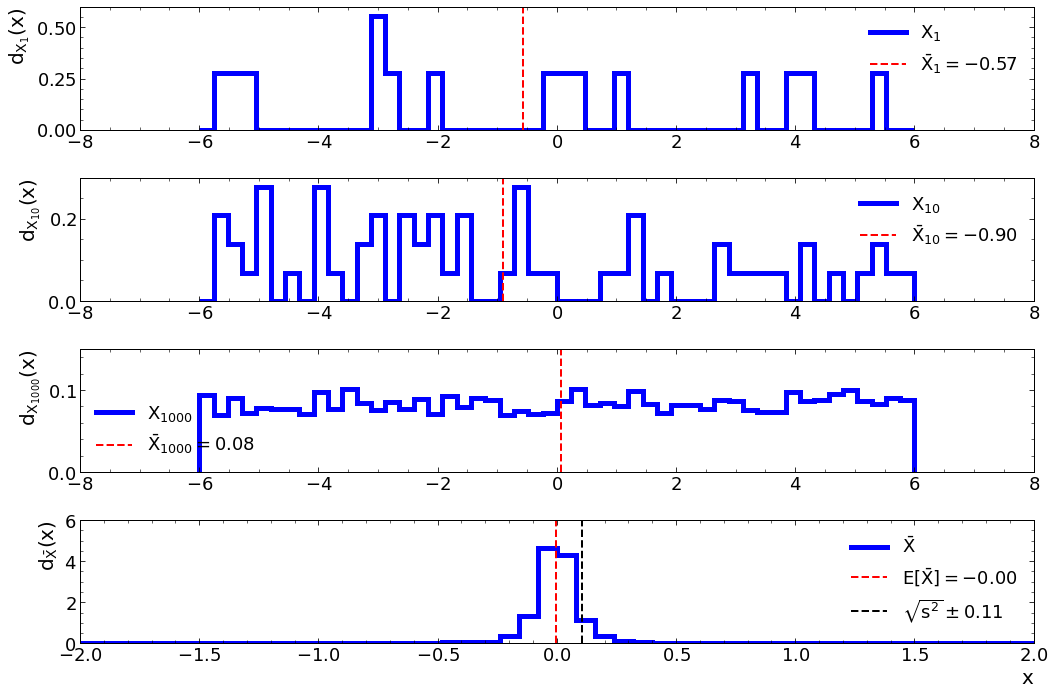

In [ ]:

xmin  = -6
xmax  = 6
nbins = 50


plt.figure(figsize=(15,10))

#
# plot do histograma para os experimentos 1, 10 e 1000
#
i = 0
plt.subplot(411)
density_obs, freq_obs, bin_edges = get_density(X_i[i], nbins=nbins, xmin=xmin, xmax=xmax)
plt.stairs(density_obs, bin_edges, fill=False,color='blue', label=r'$X_{%i}$'%(i+1), linewidth=5)
plt.axvline(calculate_mean(X_i[i]), color='red', linestyle='dashed'  , linewidth=2, label=r'$\bar{X}_{%i} = %.2f$'%(i+1, X_bar[i]))
plt.ylabel(r"$d_{X_{%i}}(x)$"%(i+1),  loc='top', fontsize=20)
plt.legend()

i = 9
plt.subplot(412)
density_obs, freq_obs, bin_edges = get_density(X_i[i], nbins=nbins, xmin=xmin, xmax=xmax)
plt.stairs(density_obs, bin_edges, fill=False,color='blue', label=r'$X_{%i}$'%(i+1), linewidth=5)
plt.ylabel(r"$d_{X_{%i}}(x)$"%(i+1),  loc='top', fontsize=20)
plt.axvline(calculate_mean(X_i[i]), color='red', linestyle='dashed'  , linewidth=2, label=r'$\bar{X}_{%i} = %.2f$'%(i+1,X_bar[i]))
plt.legend()

i = 999
plt.subplot(413)
density_obs, freq_obs, bin_edges = get_density(X_i[i], nbins=nbins, xmin=xmin, xmax=xmax)
plt.stairs(density_obs, bin_edges, fill=False,color='blue', label=r'$X_{%i}$'%(i+1), linewidth=5)
plt.ylabel(r"$d_{X_{%i}}(x)$"%(i+1),  loc='top', fontsize=20)
plt.axvline(calculate_mean(X_i[i]), color='red', linestyle='dashed'  , linewidth=2, label=r'$\bar{X}_{%i} = %.2f$'%(i+1,X_bar[i]))
plt.legend()

#
# plot do histograma das médias de todos os experimentos.
#
xmin  = -2
xmax  = 2
nbins = 50

plt.subplot(414)
density_obs, freq_obs, bin_edges = get_density(X_bar, nbins=nbins, xmin=xmin, xmax=xmax)
plt.stairs(density_obs, bin_edges, fill=False,color='blue', label=r'$\bar{X}$', linewidth=5)
plt.xlabel("x",  loc='right', fontsize=20)
plt.ylabel(r"$d_{\bar{X}}(x)$",  loc='top', fontsize=20  )
plt.xlim([xmin,xmax])
mean        = calculate_mean(X_bar)
variance    = calculate_variance(X_bar)
dp          = np.sqrt(variance)
plt.axvline(mean, color='red', linestyle='dashed'  , linewidth=2, label=r'$E[\bar{X}] = %.2f$'%mean)
plt.axvline(mean - dp, ymin=10, ymax=1, color='black', linestyle='dashed', linewidth=2, label=r'$\sqrt{s^2} \pm %1.2f$'%(dp) )
plt.axvline(mean + dp, ymin=0, ymax=1, color='black', linestyle='dashed', linewidth=2)
plt.legend()


plt.tight_layout()
plt.show()

### 3) Pergunta:

Qual a sua conclusão para o estimador de média amostral?

 Com base nos resultados obtidos, ficou claro que o **estimador de média amostral é realmente não-viesado**, como apresentado no slide 31. Ou seja, em média, ele não subestima nem superestima o valor real da média populacional. É possível notar nos valores dos meus experimentos que as médias amostrais de amostras pequenas, como X1 = -0,57 e X10 = -0,90, ainda apresentam uma boa variação, o que é esperado quando o tamanho da amostra é pequeno. No entanto, à medida que ocorre um aumento no número de experimentos, a média das médias amostrais se aproximam cada vez mais do valor teórico, conforme pode ser visto no último gráfico, em que o valor médio foi em torno de 0 e o desvio padrão das médias foi relativamente pequeno, em torno de 0,11.

 O comportamento deste experimento reforça o que foi apresentado no Módulo 1 sobre a convergência da média amostral para o valor real da população à média que o tamanho da amostra cresce, confirmando na prática o que o Teorema do Limite Central garante na Teoria.

 Apesar da teoria garantir que a distribuição das médias amostrais converge para uma curva gaussiana centrada no valor esperado da população, percebo que no meu experimento o formato não ficou perfeitamente simétrico ou liso, principalmente devido às limitações do tamanho das amostras e da quantidade de experimentos realizados. Ainda assim, é possível observar que ocorre uma concentração das médias ao redor do valor real, com uma distribuição mais próxima de um sino, como previsto pelo TLC e apresentado no Módulo 1 da disciplina. Logo, mesmo que o formato não seja exatamente igual ao ideal, a tendência gaussiana começa a aparecer e confirma, em certo modo, o que a teoria prevê.